Post-processing eccentricity posterior using [gw_eccentricity](https://github.com/vijayvarma392/gw_eccentricity)<br>
In this example, we use a parameter estimation result file from [Bilby](https://git.ligo.org/lscsoft/bilby)

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np

## Path to PE result file

In [2]:
# result_file = "/Users/arif/Desktop/TEOB_chi0_9_ecc0_1_samples.hdf5" #"/Users/arif/Desktop/TEOB_chi0_9_ecc0_3_samples.hdf5"
# injection_file = "/Users/arif/Desktop/injection_params_TEOB_chi0_9_ecc0_1_samples.dat"#"/Users/arif/Desktop/injection.dat"
result_file = "/Users/arif/Desktop/TEOB_chi0_9_ecc0_3_samples.hdf5"
injection_file = "/Users/arif/Desktop/injection.dat"

## Post-process the posterior file

For postprocessing Bilby result, we will use the derived class `PostProcessForBilby`

In [3]:
from gw_eccentricity.posterior.postprocess_for_bilby import PostProcessForBilby

/Users/arif/gw_eccentricity/gw_eccentricity/load_data.py:7: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


## create a datadict generator

In addition to the posterior result file, we need to provide a `data_dict_generator` function which given an index, representing a row in the posterior DataFrame, returns a data_dict that will be used to measure eccentricity using `gw_eccentricity.measure_eccentricity`

The intrinsic parameters (reference frequency, masses, spins, eccentricity and mean anomaly) should match the parameters used to generate the waveforms when using bilby

In [4]:
import sys
sys.path.append("/Users/arif/teobresums_reviewed/Python/")

In [5]:
from teob_backward_evolution import teob_data_dict_generator

Check that the data_dict generated using `dataDict_generator` makes sense

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

# Posteriors

Now we use the posterior result file and the `data_dict_generator` to instantiate an instance of  `PostProcessForBilby` class

In [7]:
egwBilby = PostProcessForBilby(result_file, data_dict_generator=teob_data_dict_generator,
                              data_dict_generator_extra_kwargs={"ode_tmax": 1, "backwards": "yes"},
                              injection_file=injection_file)

17:02 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


# Looking at the original posteriors

In [8]:
egwBilby.get_posterior()

,H1_log_likelihood,H1_matched_filter_snr,H1_optimal_snr,L1_log_likelihood,L1_matched_filter_snr,L1_optimal_snr,L1_time,V1_log_likelihood,V1_matched_filter_snr,V1_optimal_snr,...,spin_2x,spin_2y,spin_2z,symmetric_mass_ratio,theta_jn,tilt_1,tilt_2,total_mass,total_mass_source,waveform_approximant
0,623.536988,35.393036- 1.832653j,36.320440,832.897895,40.886870+ 0.337570j,41.362264,2.022867,79.990989,12.783959+ 0.292588j,13.283787,...,0,0,0.840667,0.241917,0.254826,0.0,0.0,117.996238,87.927810,TEOBResumSDALI
1,623.737121,35.413042- 0.219257j,36.072400,834.313813,40.934172+ 0.893366j,40.930566,2.020499,78.126882,12.680335- 1.206002j,12.763677,...,0,0,0.884071,0.247294,0.799544,0.0,0.0,117.215195,91.807840,TEOBResumSDALI
2,625.263228,35.442456- 1.632387j,35.903969,829.859150,40.812956- 0.412181j,40.807886,2.023034,82.320345,12.970347+ 0.254119j,13.072128,...,0,0,0.756452,0.239020,0.189148,0.0,0.0,116.939708,87.103236,TEOBResumSDALI
3,623.660924,35.395494- 2.728341j,34.966475,833.187739,40.892780+ 2.002818j,40.065281,2.020089,81.065828,12.864432+ 0.454741j,12.946800,...,0,0,0.868357,0.247583,0.161180,0.0,0.0,117.422422,86.382175,TEOBResumSDALI
4,627.470438,35.506280+ 0.409910j,35.208147,830.505277,40.830341- 0.528652j,39.797103,2.020817,79.868891,12.782441+ 0.623043j,12.668456,...,0,0,0.812520,0.239390,0.230434,0.0,0.0,115.367024,86.073716,TEOBResumSDALI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12723,626.550917,35.499546+ 0.073499j,36.098698,845.009001,41.201355+ 0.036744j,40.760186,2.020851,82.309320,13.023293- 0.098106j,13.410467,...,0,0,0.885188,0.249987,0.951851,0.0,0.0,118.877416,95.101984,TEOBResumSDALI
12724,626.300630,35.496080- 0.830289j,35.969990,844.760389,41.198333+ 0.404540j,40.711227,2.020917,82.643707,13.059309- 0.070462j,13.374895,...,0,0,0.881033,0.249998,1.021669,0.0,0.0,118.442282,95.681426,TEOBResumSDALI
12725,626.957177,35.513985- 0.266306j,37.514769,844.633748,41.194731+ 0.495985j,42.412076,2.020852,82.200797,13.022836- 0.172487j,13.950999,...,0,0,0.888504,0.249980,1.004888,0.0,0.0,118.374764,96.129032,TEOBResumSDALI
12726,627.806113,35.532200+ 0.171292j,37.527899,844.150416,41.177941+ 1.132581j,42.491474,2.021137,82.267627,13.011608+ 0.770148j,14.006202,...,0,0,0.890064,0.249990,0.893409,0.0,0.0,118.771925,94.895787,TEOBResumSDALI


In [9]:
injection = egwBilby.get_injection()

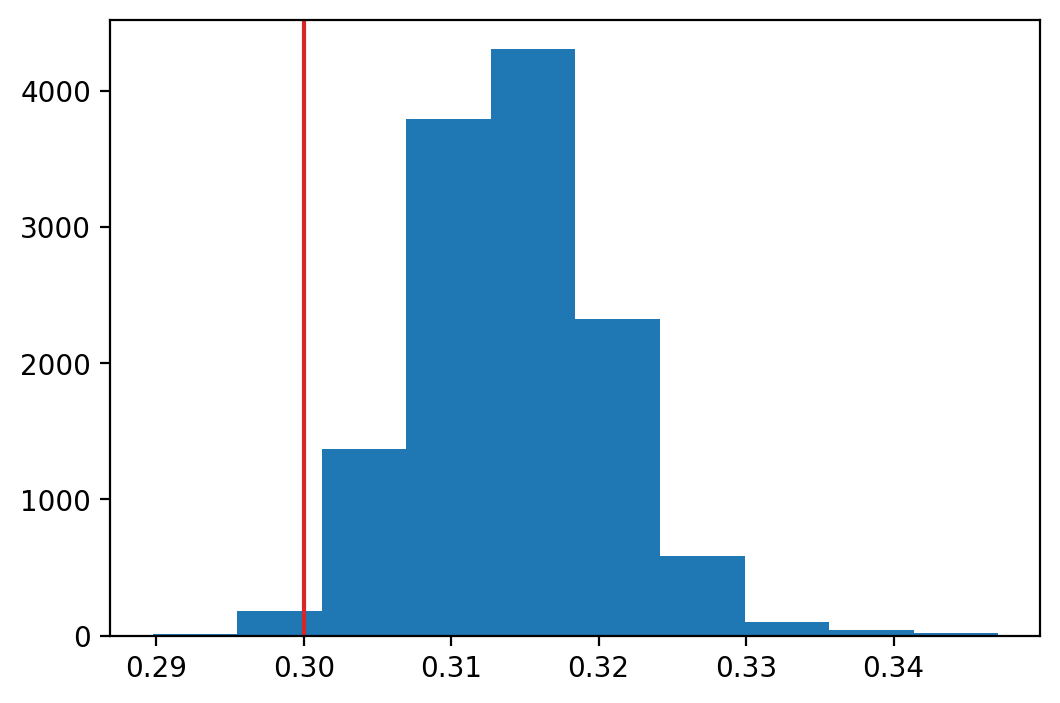

In [10]:
fig, ax = egwBilby.plot_eccentricity_posterior(**{"bins": 10})
ax.axvline(injection["eccentricity"], c="tab:red")

In [11]:
data_dict = egwBilby.get_injection_data_dict()

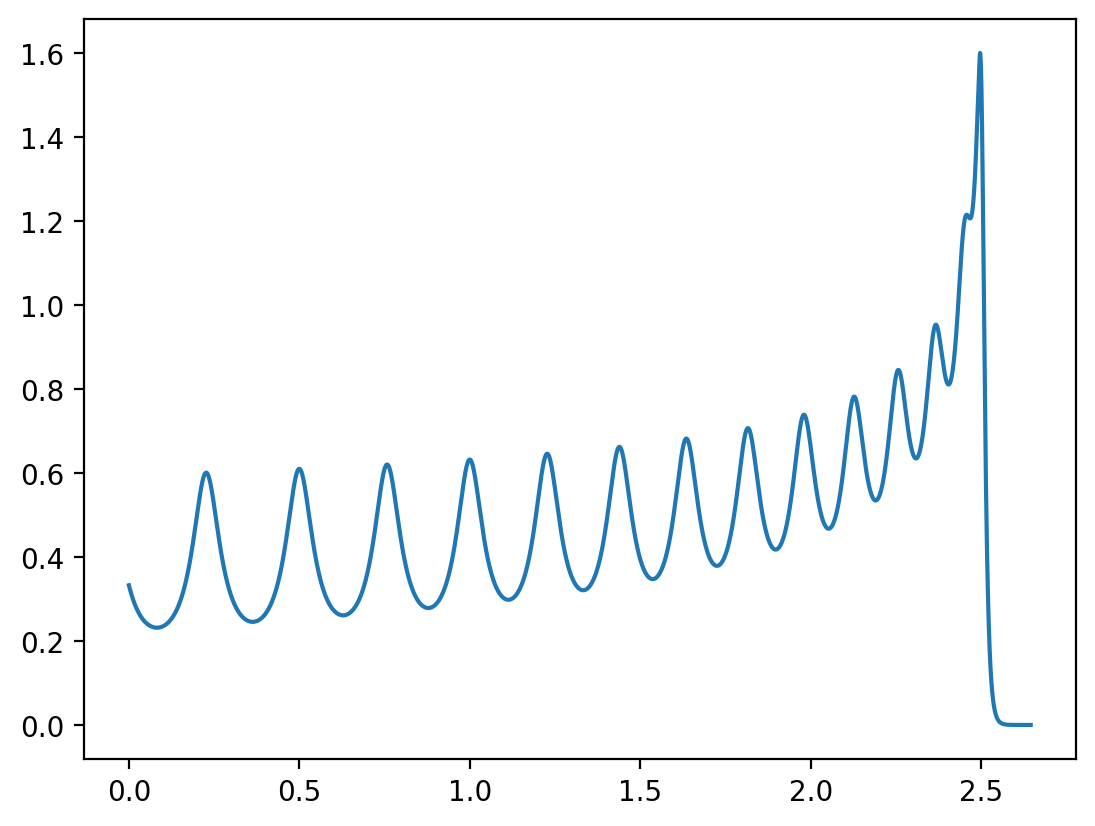

In [12]:
plt.plot(data_dict["t"], np.abs(data_dict["amplm"][(2, 2)]))

# Getting the best fref to use
Sometimes the chosen `fref`, the frequency where eccentricity and mean anomaly are to be measured could be outside the range where `egw` can be measured. Running the following code will give an idea of the `fref` bounds withing which majority of the samples can be post-processed.

This will also give an idea about how much backward evolving is required to get the orbit average frequency down to the desired `fref`.

In [13]:
from gw_eccentricity.posterior.postprocess import get_fref_bounds_for_sample

In [14]:
# some settings to use
method = "Amplitude"
gw_eccentricity_kwargs = {"extra_kwargs": {
    # "omega_gw_extrema_interpolation_method": "spline"
}}
samples = np.arange(0, 1000)
n_jobs = 6

We can check the range of frequencies where eccentricity and mean anomaly could be measured using the following method

In [15]:
params = egwBilby.posterior.iloc[0].to_dict()

In [16]:
get_fref_bounds_for_sample(
    params=params, 
    data_dict_generator=egwBilby.data_dict_generator, 
    data_dict_generator_extra_kwargs=egwBilby.data_dict_generator_extra_kwargs,
    method=method,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs
)

/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: divide by zero encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: overflow encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: invalid value encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: divide by zero encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: overflow encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: invalid value encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:409: RuntimeWarning: divide by zero encountered in matmul
  q =

{'method': 'Amplitude',
 'status': 'success',
 'fref_min': np.float64(8.505381300863787),
 'fref_max': np.float64(30.326696383834136),
 'params': {'H1_log_likelihood': 623.5369875098334,
  'H1_matched_filter_snr': np.complex128(35.39303572758314-1.832652685505252j),
  'H1_optimal_snr': 36.32044022415552,
  'L1_log_likelihood': 832.8978950522788,
  'L1_matched_filter_snr': np.complex128(40.886870487292214+0.33757000093877354j),
  'L1_optimal_snr': 41.36226439725715,
  'L1_time': 2.022867232481178,
  'V1_log_likelihood': 79.99098888699274,
  'V1_matched_filter_snr': np.complex128(12.783958777690742+0.2925876821974026j),
  'V1_optimal_snr': 13.283786977071745,
  'a_1': 0.892923508095561,
  'a_2': 0.8406665415823152,
  'chi_1': 0.892923508095561,
  'chi_1_in_plane': 0.0,
  'chi_2': 0.8406665415823152,
  'chi_2_in_plane': 0.0,
  'chi_eff': 0.8714930791712413,
  'chi_p': 0.0,
  'chirp_mass': 50.35800221829986,
  'chirp_mass_source': 37.5255088352051,
  'comoving_distance': 1388.6145934844596

Get the range of frequencies where we can measure egw and lgw. We take only a few samples to see this to save time.

In [17]:
egwBilby.get_fref_bounds(samples=samples,
                         method=method,
                         n_jobs=n_jobs,
                         gw_eccentricity_kwargs=gw_eccentricity_kwargs
                        )

Getting fref bounds:   0%|                                                                                                                                                          | 0/1000 [00:00<?, ?it/s]/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: divide by zero encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: overflow encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: invalid value encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: divide by zero encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: overflow encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational

{'fref_bounds': (np.float64(8.66997243912156), np.float64(29.323682672732204)),
 'success_percentage': 100.0,
 'failed_cases': []}

# Post-processing

We can measure eccentricity and mean anomaly for any sample using the following method

In [18]:
from gw_eccentricity.posterior.postprocess import postprocess_sample

Post-process a given sample

In [19]:
fref = 10
postprocess_sample(
    params=params,
    data_dict_generator=egwBilby.data_dict_generator,
    data_dict_generator_extra_kwargs=egwBilby.data_dict_generator_extra_kwargs,
    fref=fref,
    method=method,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs)

/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: divide by zero encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: overflow encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: invalid value encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: divide by zero encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: overflow encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: invalid value encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:409: RuntimeWarning: divide by zero encountered in matmul
  q =

{'status': 'success',
 'egw': np.float64(0.35295629029966646),
 'lgw': np.float64(4.564859417630309)}

We can postprocess a subset of the smaples or all the samples using the following method

In [20]:
import time

In [21]:
fref = 10
t_start = time.perf_counter()
egwBilby.postprocess(fref=fref, samples=samples,
                      method=method,
                      gw_eccentricity_kwargs=gw_eccentricity_kwargs,
                      n_jobs=n_jobs)
t_stop = time.perf_counter()

Postprocessing samples:  16%|██████████████████████▊                                                                                                                      | 162/1000 [00:05<00:29, 28.13it/s]/Users/arif/gw_eccentricity/gw_eccentricity/eccDefinition.py:1723: UserWarning: Nonmonotonic time derivative detected in the rational_fit interpolant through pericenters. 
  debug_message(
Postprocessing samples:  35%|█████████████████████████████████████████████████                                                                                            | 348/1000 [00:12<00:24, 26.82it/s]/Users/arif/gw_eccentricity/gw_eccentricity/eccDefinition.py:2725: UserWarning: egw(t) is nonmonotonic in the range [np.float64(2.358154296875), np.float64(2.359375)]
For more verbose output use `debug_level=1`.
  debug_message(message, self.debug_level,
Postprocessing samples:  61%|█████████████████████████████████████████████████████████████████████████████████████▍                               

In [22]:
print(f"Took {t_stop - t_start} seconds for {len(samples)} samples on {n_jobs} cores.")

Took 38.02751512500072 seconds for 1000 samples on 6 cores.


## View the results

In [24]:
egwBilby.postprocess_result[:5]

[{'status': 'success',
  'egw': np.float64(0.35295629029966646),
  'lgw': np.float64(4.564859417630309)},
 {'status': 'success',
  'egw': np.float64(0.3494586441974693),
  'lgw': np.float64(4.785220809941226)},
 {'status': 'success',
  'egw': np.float64(0.35928887737263804),
  'lgw': np.float64(4.393433188765819)},
 {'status': 'success',
  'egw': np.float64(0.33021729191815896),
  'lgw': np.float64(2.606909542975531)},
 {'status': 'success',
  'egw': np.float64(0.3563477644101737),
  'lgw': np.float64(2.9587641053822615)}]

In [25]:
egw_inj, mean_ano_inj = egwBilby.get_injection_eccentricity(
    fref=fref,
    method=method,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs,
    # debug=True
)

/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: divide by zero encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: overflow encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:107: RuntimeWarning: invalid value encountered in matmul
  v = V[:, k] * x - V[:, :k+1] @ H[:k+1, k]
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: divide by zero encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: overflow encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:408: RuntimeWarning: invalid value encountered in matmul
  p = P @ self.a
/Users/arif/gw_eccentricity/gw_eccentricity/rational_fit.py:409: RuntimeWarning: divide by zero encountered in matmul
  q =

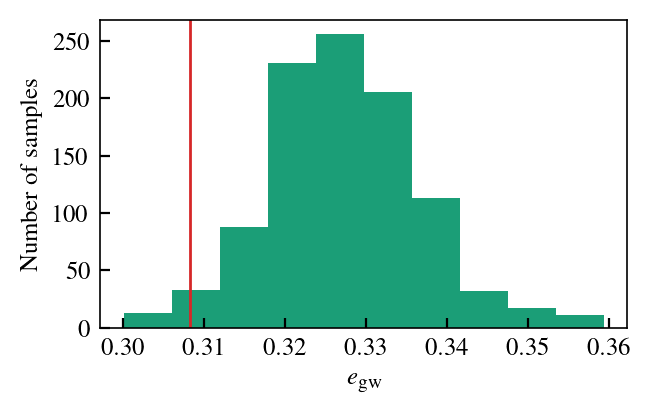

In [26]:
fig, ax = egwBilby.plot_egw_posterior(usetex=True, style="APS")
ax.axvline(egw_inj, c="tab:red")

(<Figure size 600x400 with 1 Axes>, <Axes: >)

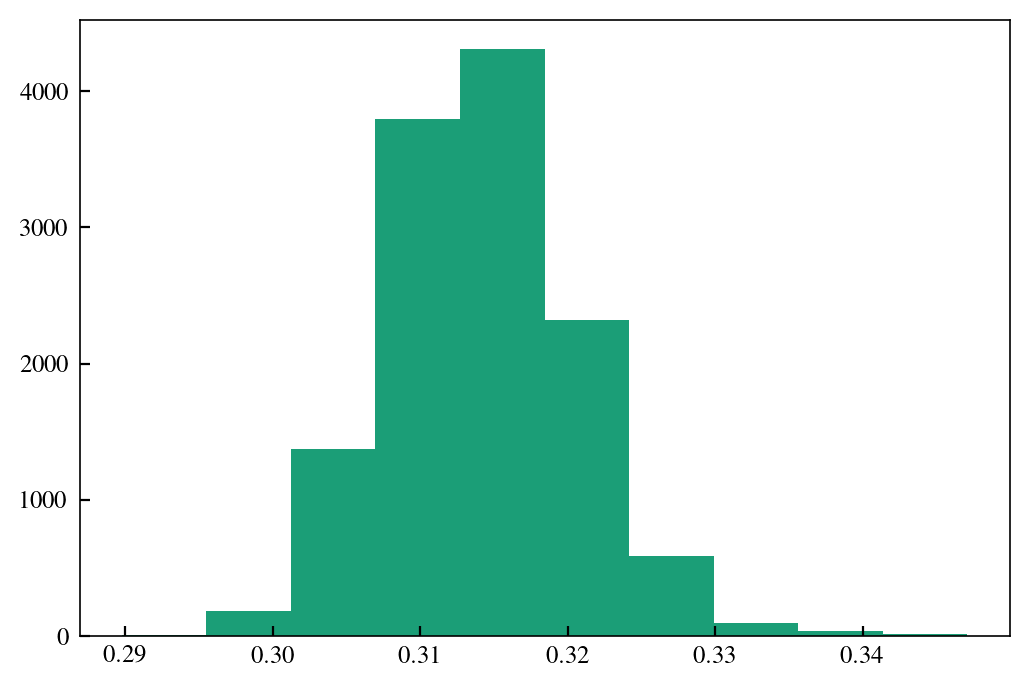

In [27]:
egwBilby.plot_eccentricity_posterior()

## Get a summary of the post-process, like how many cases were successfully post-processed

In [28]:
egwBilby.postprocess_summary()

{'total_samples': 1000,
 'success_percentage': 100.0,
 'egw': [np.float64(0.35295629029966646),
  np.float64(0.3494586441974693),
  np.float64(0.35928887737263804),
  np.float64(0.33021729191815896),
  np.float64(0.3563477644101737),
  np.float64(0.3577378365805802),
  np.float64(0.3580607922740866),
  np.float64(0.35205633555792437),
  np.float64(0.3534807354034398),
  np.float64(0.35557319687088185),
  np.float64(0.33356401677184955),
  np.float64(0.3360351878328922),
  np.float64(0.3519785511087392),
  np.float64(0.3220889071724744),
  np.float64(0.3411397709090993),
  np.float64(0.3570574308159199),
  np.float64(0.3535213299603588),
  np.float64(0.34692717954533203),
  np.float64(0.3367593617982253),
  np.float64(0.33301899586984085),
  np.float64(0.3259568463012411),
  np.float64(0.31679584378337056),
  np.float64(0.3358535302159821),
  np.float64(0.3305781091080515),
  np.float64(0.3429594256491535),
  np.float64(0.35109026466464577),
  np.float64(0.3567899436277384),
  np.float6